In [234]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

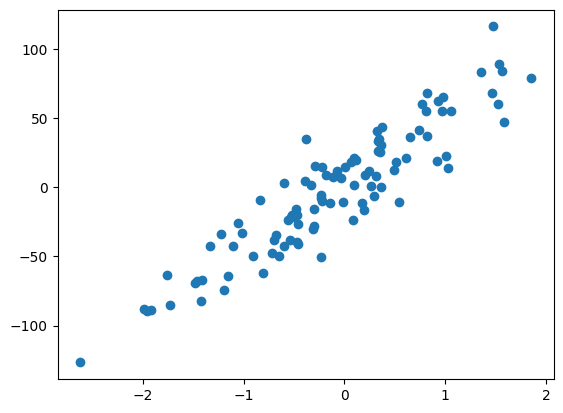

In [235]:
x,y = make_regression(n_samples=100,n_features=1,noise=20,random_state=42)
plt.scatter(x,y)

In [236]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x,y)
print(model.coef_,model.intercept_)


[47.13323967] 2.3302306410539453


In [237]:
from sklearn.linear_model import Ridge
model1 = Ridge(alpha=10)
model1.fit(x,y)
print(model1.coef_,model1.intercept_)

[41.9906212] 1.7961876226164746


In [238]:

model2 = Ridge(alpha=100)
model2.fit(x,y)
print(model2.coef_,model2.intercept_)

[21.18627364] -0.3642714175995887


In [239]:
model3 = Ridge(alpha=1)
model3.fit(x,y)
print(model3.coef_,model3.intercept_)

[46.56297985] 2.27101114489746


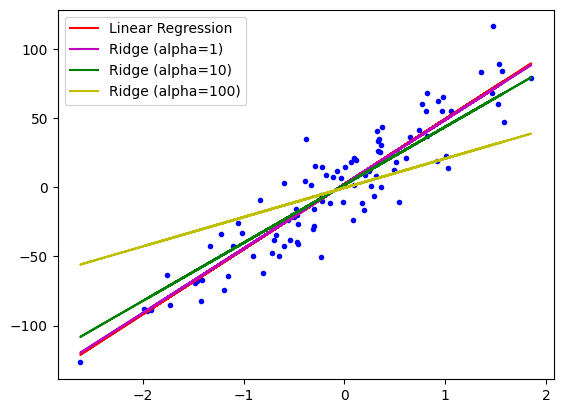

In [240]:
plt.plot(x,y,'b.')
plt.plot(x,model.predict(x),'r-',label='Linear Regression')
plt.plot(x,model3.predict(x),'m-',label='Ridge (alpha=1)')  
plt.plot(x,model1.predict(x),'g-',label='Ridge (alpha=10)')
plt.plot(x,model2.predict(x),'y-',label='Ridge (alpha=100)')

plt.legend()

In [241]:

class MeraRidge:
    
    def __init__(self,alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())
        
        self.m = num/(den + self.alpha)
        self.b = y_train.mean() - (self.m*X_train.mean())
        print(self.m,self.b)
    
    def predict(self,X_test):
        return self.m * X_test + self.b

In [242]:
reg = MeraRidge(alpha=100)
reg.fit(x,y)

[21.18627364] [-0.36427142]


## for nd data


In [243]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

In [244]:
x,y = load_diabetes(return_X_y=True)

In [245]:
from sklearn.model_selection import train_test_split

In [246]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=4) 

In [247]:
from sklearn.linear_model import Ridge
model4 = Ridge(alpha=1.0,solver='cholesky')

In [248]:
model4.fit(x_train,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'cholesky'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",No

In [249]:
y_pred = model4.predict(x_test)

In [250]:
r2_score(y_test,y_pred)

0.4093881140127431

In [251]:
print(model4.coef_,model4.intercept_)

[  48.81261163  -85.49430983  270.22640536  201.91604765   17.41348052
  -19.04307488 -136.47735722  122.26517107  247.59846265   95.59879746] 151.29748677566116


In [252]:

class MeraRidge:
    
    def __init__(self,alpha=1.0):
        
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,x_train,y_train):
        
        x_train = np.insert(x_train,0,1,axis=1)
        I = np.identity(x_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(x_train.T,x_train) + self.alpha * I).dot(x_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
    def predict(self,x_test):
        return np.dot(x_test,self.coef_) + self.intercept_

In [253]:

reg = MeraRidge()
reg.fit(x_train,y_train)
y_pred = reg.predict(x_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.4093881140127432
[  48.81261163  -85.49430983  270.22640536  201.91604765   17.41348052
  -19.04307488 -136.47735722  122.26517107  247.59846265   95.59879746]
151.29748677566118


## Using Gradient Descent


In [254]:
from sklearn.linear_model import SGDRegressor

In [255]:
reg1 = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [256]:

reg1.fit(x_train,y_train)

y_pred = reg1.predict(x_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg1.coef_)
print(reg1.intercept_)

R2 score 0.45469750919899177
[  54.01756679 -131.57384237  354.18903724  259.51576025    3.61633162
  -47.45740898 -167.41596245  143.14630248  315.84995725  105.45307944]
[158.36007737]


In [257]:


reg3 = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [258]:

reg3.fit(x_train,y_train)

y_pred = reg3.predict(x_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg3.coef_)
print(reg3.intercept_)

R2 score 0.4625010162009602
[  34.52192661 -290.84083974  482.4018151   368.06786776 -852.44872998
  501.59160516  180.11115631  270.76334212  759.73534588   37.49135628]
151.10198517848258


In [262]:
class MeraRidgeGD:

    def __init__(self, epochs, learning_rate, alpha):

        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None

    def fit(self, x_train, y_train):

        self.coef_ = np.ones(x_train.shape[1])
        self.intercept_ = 0

        theta = np.insert(self.coef_, 0, self.intercept_)

        x_train = np.insert(x_train, 0, 1, axis=1)

        for i in range(self.epochs):

            reg_term = self.alpha * theta
            reg_term[0] = 0      # Don't regularize intercept

            theta_der = (
                np.dot(x_train.T, x_train).dot(theta)
                - np.dot(x_train.T, y_train)
                + reg_term
            )

            theta = theta - self.learning_rate * theta_der

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]

    def predict(self, x_test):

        return np.dot(x_test, self.coef_) + self.intercept_

In [263]:

reg4 = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [264]:

reg4.fit(x_train,y_train)

y_pred = reg4.predict(x_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg4.coef_)
print(reg4.intercept_)

R2 score 0.47380283051527006
[  46.65030722 -221.37477332  452.12073758  325.54232116  -29.09454705
  -96.47500036 -190.90007212  146.32917061  400.80277232   95.09025567]
150.87018209497242
